In [14]:
import pandas as pd
import numpy as np
from datetime import datetime
from typing import List, Dict, Tuple, Optional
from uuid import uuid4
import hashlib
import os

# ============================================================================
# GRANT ALLOCATION ENGINE CLASS
# ============================================================================

class GrantAllocationEngine:
    """
    Main engine for allocating expenses to grants based on defined business rules.
    """

    def __init__(self, grants_df: pd.DataFrame, transactions_df: pd.DataFrame):
        """
        Initialize the allocation engine with grants and transactions data.
        """
        self.grants_df = grants_df.copy()
        self.transactions_df = transactions_df.copy()
        self.allocations = []
        self.unallocated = []
        self.allocation_complete = False  # Flag to prevent re-running

        # Pre-process data
        self._prepare_data()

    def _prepare_data(self):
        """Convert date columns and initialize tracking columns."""
        # Convert date columns to datetime
        date_columns = ['StartDate', 'EndDate']
        for col in date_columns:
            if col in self.grants_df.columns:
                self.grants_df[col] = pd.to_datetime(self.grants_df[col])

        if 'TransactionDate' in self.transactions_df.columns:
            self.transactions_df['TransactionDate'] = pd.to_datetime(
                self.transactions_df['TransactionDate']
            )

        # Initialize remaining budget for each grant
        self.grants_df['RemainingBudget'] = self.grants_df['TotalAmount'].copy()

        # Add allocation tracking columns to transactions
        self.transactions_df['AllocatedAmount'] = 0.0
        self.transactions_df['AllocationStatus'] = 'Pending'

    def _is_transaction_eligible_for_grant(self, transaction: pd.Series, grant: pd.Series) -> bool:
        """
        Check if a transaction is eligible for a specific grant based on rules.
        """
        # Check date range
        if not (grant['StartDate'] <= transaction['TransactionDate'] <= grant['EndDate']):
            return False

        # Check remaining budget
        if grant['RemainingBudget'] <= 0:
            return False

        # Define restriction columns to check
        restriction_cols = ['BusinessUnit', 'Country', 'Account', 'ProjectName', 'DepartmentName']

        # Check each restriction column
        for col in restriction_cols:
            if col in grant.index and col in transaction.index:
                grant_value = grant[col]
                trans_value = transaction[col]

                # NULL in grant means wildcard (matches anything)
                if pd.isna(grant_value) or grant_value == '' or grant_value is None:
                    continue

                # If grant has a value, transaction must match exactly
                if pd.isna(trans_value) or grant_value != trans_value:
                    return False

        return True

    def _get_eligible_grants(self, transaction: pd.Series) -> pd.DataFrame:
        """
        Find all grants eligible for a given transaction.
        """
        eligible_mask = self.grants_df.apply(
            lambda grant: self._is_transaction_eligible_for_grant(transaction, grant),
            axis=1
        )

        eligible_grants = self.grants_df[eligible_mask].copy()

        # Sort by Priority ASC (lower number = higher priority), then EndDate ASC
        eligible_grants = eligible_grants.sort_values(
            by=['Priority', 'EndDate'],
            ascending=[True, True]
        )

        return eligible_grants

    def _allocate_amount_to_grant(self, grant: pd.Series, amount: float) -> Tuple[float, float]:
        """
        Allocate a specific amount to a grant, respecting remaining budget.
        """
        if grant['RemainingBudget'] >= amount:
            allocated = amount
            remaining = 0
        else:
            allocated = grant['RemainingBudget']
            remaining = amount - grant['RemainingBudget']

        return allocated, remaining

    def run_allocation(self) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """
        Execute the complete allocation process.
        Only runs once - subsequent calls return cached results.
        """
        # Return cached results if allocation already done
        if self.allocation_complete:
            allocations_df = pd.DataFrame(self.allocations) if self.allocations else pd.DataFrame()
            unallocated_df = pd.DataFrame(self.unallocated) if self.unallocated else pd.DataFrame()
            burn_rate_df = self._calculate_burn_rate()
            return allocations_df, unallocated_df, burn_rate_df

        # Sort transactions by date (earliest first)
        sorted_transactions = self.transactions_df.sort_values('TransactionDate')

        # Generate batch ID for idempotency
        batch_id = self._generate_batch_id()
        timestamp = datetime.now()

        # Reset allocations and unallocated tracking
        self.allocations = []
        self.unallocated = []

        # Reset allocated amount in transactions
        self.transactions_df['AllocatedAmount'] = 0.0
        self.transactions_df['AllocationStatus'] = 'Pending'

        for idx, transaction in sorted_transactions.iterrows():
            remaining_amount = transaction['Amount']
            transaction_id = transaction['TransactionId']

            # Get eligible grants for this transaction
            eligible_grants = self._get_eligible_grants(transaction)

            if eligible_grants.empty:
                # No eligible grants found - entire amount is unallocated
                self.unallocated.append({
                    'TransactionId': transaction_id,
                    'Amount': remaining_amount,
                    'Reason': 'No eligible grants available',
                    'TransactionDate': transaction['TransactionDate']
                })
                self.transactions_df.at[idx, 'AllocatedAmount'] = 0
                self.transactions_df.at[idx, 'AllocationStatus'] = 'Unallocated'
                continue

            # Track total allocated for this transaction
            total_allocated_this_transaction = 0

            # Allocate across eligible grants until fully allocated or no grants left
            for grant_idx, grant in eligible_grants.iterrows():
                if remaining_amount <= 0:
                    break

                # Allocate as much as possible to this grant
                allocated_amount, remaining_amount = self._allocate_amount_to_grant(
                    grant, remaining_amount
                )

                if allocated_amount > 0:
                    # Record allocation
                    allocation_record = {
                        'AllocationId': str(uuid4()),
                        'TransactionId': transaction_id,
                        'GrantCode': grant['GrantCode'],
                        'GrantName': grant['GrantName'],
                        'AllocatedAmount': allocated_amount,
                        'AllocationTimestamp': timestamp,
                        'AllocationBatchId': batch_id,
                        'AllocationOrder': len(self.allocations) + 1
                    }
                    self.allocations.append(allocation_record)
                    total_allocated_this_transaction += allocated_amount

                    # Update grant's remaining budget
                    grant_idx_in_df = self.grants_df[
                        self.grants_df['GrantCode'] == grant['GrantCode']
                    ].index[0]
                    self.grants_df.at[grant_idx_in_df, 'RemainingBudget'] -= allocated_amount

            # Store the allocated amount for this transaction
            self.transactions_df.at[idx, 'AllocatedAmount'] = total_allocated_this_transaction

            # Track unallocated portion if any
            if remaining_amount > 0:
                self.transactions_df.at[idx, 'AllocationStatus'] = 'Partial'
                self.unallocated.append({
                    'TransactionId': transaction_id,
                    'Amount': remaining_amount,
                    'Reason': 'Insufficient grant budgets',
                    'TransactionDate': transaction['TransactionDate'],
                    'OriginalAmount': transaction['Amount'],
                    'AllocatedAmount': total_allocated_this_transaction
                })
            else:
                self.transactions_df.at[idx, 'AllocationStatus'] = 'Fully Allocated'

        # Mark allocation as complete
        self.allocation_complete = True

        # Create DataFrames for outputs
        allocations_df = pd.DataFrame(self.allocations) if self.allocations else pd.DataFrame()
        unallocated_df = pd.DataFrame(self.unallocated) if self.unallocated else pd.DataFrame()

        # Remove duplicate unallocated entries (if any)
        if not unallocated_df.empty and 'TransactionId' in unallocated_df.columns:
            unallocated_df = unallocated_df.drop_duplicates(subset=['TransactionId'], keep='first')

        # Calculate burn rate report
        burn_rate_df = self._calculate_burn_rate()

        # Validation check
        total_expenses = self.transactions_df['Amount'].sum()
        total_allocated_check = self.transactions_df['AllocatedAmount'].sum()
        total_unallocated_check = unallocated_df['Amount'].sum() if not unallocated_df.empty else 0

        # The sum of allocated + unallocated should equal total expenses (within rounding)
        if abs((total_allocated_check + total_unallocated_check) - total_expenses) > 0.01:
            print(f"Warning: Allocation mismatch detected!")
            print(f"  Total expenses: {total_expenses:,.2f}")
            print(f"  Total allocated: {total_allocated_check:,.2f}")
            print(f"  Total unallocated: {total_unallocated_check:,.2f}")
            print(f"  Sum: {total_allocated_check + total_unallocated_check:,.2f}")

        return allocations_df, unallocated_df, burn_rate_df

    def _calculate_burn_rate(self) -> pd.DataFrame:
        """
        Calculate burn rate for each grant (allocated amount / total amount).
        """
        if not self.allocations:
            allocations_df = pd.DataFrame(columns=['GrantCode', 'AllocatedAmount'])
        else:
            allocations_df = pd.DataFrame(self.allocations)

        # Aggregate allocations by grant
        allocated_summary = allocations_df.groupby('GrantCode')['AllocatedAmount'].sum().reset_index()
        allocated_summary.rename(columns={'AllocatedAmount': 'AllocatedAmount'}, inplace=True)

        # Merge with grants data
        burn_rate = self.grants_df[['GrantCode', 'GrantName', 'Priority', 'TotalAmount', 'RemainingBudget']].copy()
        burn_rate = burn_rate.merge(allocated_summary, on='GrantCode', how='left')
        burn_rate['AllocatedAmount'] = burn_rate['AllocatedAmount'].fillna(0)
        burn_rate['BurnRate'] = burn_rate['AllocatedAmount'] / burn_rate['TotalAmount']
        burn_rate['Utilization'] = (burn_rate['TotalAmount'] - burn_rate['RemainingBudget']) / burn_rate['TotalAmount']
        burn_rate['Status'] = burn_rate.apply(
            lambda row: 'Exhausted' if row['RemainingBudget'] <= 0 else 'Active',
            axis=1
        )

        return burn_rate

    def _generate_batch_id(self) -> str:
        """
        Generate a unique batch ID for idempotency tracking.
        """
        # Create a hash of the input data for deterministic batch ID
        try:
            grants_hash = hashlib.md5(
                pd.util.hash_pandas_object(self.grants_df, index=True).values.tobytes()
            ).hexdigest()[:8]

            transactions_hash = hashlib.md5(
                pd.util.hash_pandas_object(self.transactions_df, index=True).values.tobytes()
            ).hexdigest()[:8]
        except:
            # Fallback for older pandas versions
            grants_hash = hashlib.md5(str(self.grants_df.shape).encode()).hexdigest()[:8]
            transactions_hash = hashlib.md5(str(self.transactions_df.shape).encode()).hexdigest()[:8]

        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

        return f"batch_{timestamp}_{grants_hash}_{transactions_hash}"

    def generate_summary_report(self) -> Dict:
        """
        Generate a comprehensive summary report of the allocation results.
        """
        allocations_df, unallocated_df, burn_rate_df = self.run_allocation()

        # All totals come from the transaction dataframe for consistency
        total_expenses = self.transactions_df['Amount'].sum()
        total_allocated = self.transactions_df['AllocatedAmount'].sum()
        total_unallocated = unallocated_df['Amount'].sum() if not unallocated_df.empty else 0

        report = {
            'summary': {
                'total_expenses': float(total_expenses),
                'total_allocated': float(total_allocated),
                'total_unallocated': float(total_unallocated),
                'allocation_rate': (total_allocated / total_expenses * 100) if total_expenses > 0 else 0,
                'unallocated_rate': (total_unallocated / total_expenses * 100) if total_expenses > 0 else 0,
                'transactions_processed': len(self.transactions_df),
                'transactions_fully_allocated': len(self.transactions_df[self.transactions_df['AllocationStatus'] == 'Fully Allocated']),
                'transactions_partially_allocated': len(self.transactions_df[self.transactions_df['AllocationStatus'] == 'Partial']),
                'transactions_unallocated': len(self.transactions_df[self.transactions_df['AllocationStatus'] == 'Unallocated']),
                'number_of_allocations': len(self.allocations),
                'grants_utilized': len(burn_rate_df[burn_rate_df['AllocatedAmount'] > 0]) if not burn_rate_df.empty else 0,
                'grants_exhausted': len(burn_rate_df[burn_rate_df['Status'] == 'Exhausted']) if not burn_rate_df.empty else 0
            },
            'burn_rate_summary': burn_rate_df.to_dict('records') if not burn_rate_df.empty else [],
            'unallocated_transactions': unallocated_df.to_dict('records') if not unallocated_df.empty else [],
            'allocations_preview': allocations_df.head(10).to_dict('records') if not allocations_df.empty else []
        }

        return report

    def save_outputs(self, output_dir: str = 'allocation_outputs'):
        """
        Save all outputs to CSV files for audit and reporting.
        """
        os.makedirs(output_dir, exist_ok=True)

        # Run allocation once and reuse results
        allocations_df, unallocated_df, burn_rate_df = self.run_allocation()

        # Save main outputs
        if not allocations_df.empty:
            allocations_df.to_csv(f'{output_dir}/allocations.csv', index=False)

        if not unallocated_df.empty:
            unallocated_df.to_csv(f'{output_dir}/unallocated_transactions.csv', index=False)

        if not burn_rate_df.empty:
            burn_rate_df.to_csv(f'{output_dir}/burn_rate_report.csv', index=False)

        # Save updated transactions with allocation status
        self.transactions_df.to_csv(f'{output_dir}/transactions_with_status.csv', index=False)

        # Save grants with remaining budgets
        self.grants_df.to_csv(f'{output_dir}/grants_remaining_budgets.csv', index=False)

        print(f"Outputs saved to '{output_dir}/' directory")


# ============================================================================
# GOOGLE COLAB COMPATIBLE MAIN FUNCTION
# ============================================================================

def load_data_for_colab(grants_path: str, expenses_path: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load grants and expenses data specifically for Google Colab.
    """
    print(f"\nAttempting to load files...")
    print(f"   Grants file: {grants_path}")
    print(f"   Expenses file: {expenses_path}")

    # Check if files exist
    if not os.path.exists(grants_path):
        raise FileNotFoundError(f"Grants file not found at: {grants_path}")

    if not os.path.exists(expenses_path):
        raise FileNotFoundError(f"Expenses file not found at: {expenses_path}")

    # Load CSV files
    grants_df = pd.read_csv(grants_path)
    expenses_df = pd.read_csv(expenses_path)

    # Clean up column names (remove any whitespace)
    grants_df.columns = grants_df.columns.str.strip()
    expenses_df.columns = expenses_df.columns.str.strip()

    # Handle missing values - replace NaN with None for proper wildcard handling
    grants_df = grants_df.replace({np.nan: None, '': None})
    expenses_df = expenses_df.replace({np.nan: None, '': None})

    # Convert date columns if they exist
    date_columns = ['StartDate', 'EndDate']
    for col in date_columns:
        if col in grants_df.columns:
            grants_df[col] = pd.to_datetime(grants_df[col])

    if 'TransactionDate' in expenses_df.columns:
        expenses_df['TransactionDate'] = pd.to_datetime(expenses_df['TransactionDate'])

    return grants_df, expenses_df


def run_in_colab(grants_file: str = 'grants.csv',
              expenses_file: str = 'expenses.csv',
              output_dir: str = 'allocation_outputs'):
    """
    Main function to run the allocation engine in Google Colab.
    """
    print("=" * 80)
    print("GRANT EXPENSE ALLOCATION ENGINE")
    print("One Acre Fund - Data Engineering Exercise")
    print("Google Colab Version")
    print("=" * 80)

    # Get the current working directory
    current_dir = os.getcwd()
    print(f"\nCurrent working directory: {current_dir}")

    # List files in current directory
    print(f"\nFiles in current directory:")
    for file in os.listdir(current_dir):
        if file.endswith('.csv'):
            print(f"   - {file}")

    # Construct full paths
    grants_path = os.path.join(current_dir, grants_file)
    expenses_path = os.path.join(current_dir, expenses_file)

    try:
        # Load data
        grants_df, expenses_df = load_data_for_colab(grants_path, expenses_path)

        print(f"\nSuccessfully loaded:")
        print(f"   - {len(grants_df)} grants")
        print(f"   - {len(expenses_df)} transactions")

    except FileNotFoundError as e:
        print(f"\nError: {e}")
        print("\nTroubleshooting tips:")
        print("   1. Make sure you've uploaded your CSV files to Colab")
        print("   2. Run this cell first to upload files:")
        print("      from google.colab import files")
        print("      uploaded = files.upload()")
        print("   3. Then check the filenames match exactly")
        return None, None
    except Exception as e:
        print(f"\nError loading data: {e}")
        return None, None

    # Initialize and run engine
    print("\nRunning allocation engine...")
    engine = GrantAllocationEngine(grants_df, expenses_df)

    # Generate report
    report = engine.generate_summary_report()

    # Display summary
    print("\n" + "=" * 80)
    print("ALLOCATION SUMMARY REPORT")
    print("=" * 80)

    summary = report['summary']
    print(f"\nOverall Statistics:")
    print(f"   Total Expenses:        ${summary['total_expenses']:,.2f}")
    print(f"   Total Allocated:       ${summary['total_allocated']:,.2f}")
    print(f"   Total Unallocated:     ${summary['total_unallocated']:,.2f}")
    print(f"   Allocation Rate:       {summary['allocation_rate']:.1f}%")
    print(f"   Unallocated Rate:      {summary['unallocated_rate']:.1f}%")

    # Check for allocation logic error
    if summary['allocation_rate'] > 100:
        print(f"\nERROR: Allocation rate exceeds 100% - this should not happen")
        print(f"   Please check the allocation logic")

    # Save outputs
    print(f"\nSaving outputs to '{output_dir}/' directory...")
    engine.save_outputs(output_dir)

    print("\nAllocation complete!")
    print(f"\nOutput files saved to '{output_dir}/' directory:")

    return engine, report


# ============================================================================
# QUICK START FOR GOOGLE COLAB
# ============================================================================

def colab_quick_start():
    """
    Quick start function for Google Colab with file upload.
    """
    from google.colab import files

    print("=" * 80)
    print("GOOGLE COLAB QUICK START")
    print("=" * 80)

    print("\nPlease upload your CSV files:")
    print("   1. grants.csv")
    print("   2. expenses.csv")
    print("\nClick 'Choose Files' and select both files.\n")

    uploaded = files.upload()

    print("\nFiles uploaded successfully!")
    print("Uploaded files:")
    for filename in uploaded.keys():
        print(f"   - {filename}")

    print("\nReady to run allocation engine!")
    print("Run the next cell with: run_in_colab('grants.csv', 'expenses.csv')")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # For Google Colab, run the cells sequentially:
    # Step 1: Upload files (uncomment to run)
    # colab_quick_start()

    # Step 2: Run the allocation engine
    run_in_colab('grants.csv', 'expenses.csv')

GRANT EXPENSE ALLOCATION ENGINE
One Acre Fund - Data Engineering Exercise
Google Colab Version

Current working directory: /content

Files in current directory:
   - grants.csv
   - expenses.csv

Attempting to load files...
   Grants file: /content/grants.csv
   Expenses file: /content/expenses.csv

Successfully loaded:
   - 500 grants
   - 25000 transactions

Running allocation engine...

ALLOCATION SUMMARY REPORT

Overall Statistics:
   Total Expenses:        $100,618,782.00
   Total Allocated:       $86,193,285.00
   Total Unallocated:     $14,425,497.00
   Allocation Rate:       85.7%
   Unallocated Rate:      14.3%

Saving outputs to 'allocation_outputs/' directory...
Outputs saved to 'allocation_outputs/' directory

Allocation complete!

Output files saved to 'allocation_outputs/' directory:


In [15]:
# ============================================================================
# BASIC COUNTS AND KPIS - First Analysis
# ============================================================================

import pandas as pd
import os

def load_and_analyze_basic_metrics(output_dir='allocation_outputs'):
    """Load output files and calculate basic KPIs"""

    print("="*80)
    print("GRANT ALLOCATION - BASIC COUNTS & KPIS")
    print("="*80)

    # Load the output files
    allocations_df = pd.read_csv(f'{output_dir}/allocations.csv') if os.path.exists(f'{output_dir}/allocations.csv') else None
    unallocated_df = pd.read_csv(f'{output_dir}/unallocated_transactions.csv') if os.path.exists(f'{output_dir}/unallocated_transactions.csv') else None
    burn_rate_df = pd.read_csv(f'{output_dir}/burn_rate_report.csv') if os.path.exists(f'{output_dir}/burn_rate_report.csv') else None
    transactions_df = pd.read_csv(f'{output_dir}/transactions_with_status.csv') if os.path.exists(f'{output_dir}/transactions_with_status.csv') else None
    grants_df = pd.read_csv(f'{output_dir}/grants_remaining_budgets.csv') if os.path.exists(f'{output_dir}/grants_remaining_budgets.csv') else None

    if burn_rate_df is None:
        print("No burn_rate_report.csv found. Please run allocation engine first.")
        return

    # Basic counts
    print("\n1. BASIC COUNTS")
    print("-" * 40)

    total_grants = len(burn_rate_df)
    print(f"Total grants: {total_grants}")

    if transactions_df is not None:
        total_transactions = len(transactions_df)
        print(f"Total transactions: {total_transactions}")

    if allocations_df is not None:
        total_allocations = len(allocations_df)
        print(f"Total allocation records: {total_allocations}")

    # Allocation status
    print("\n2. ALLOCATION STATUS")
    print("-" * 40)

    # Count grants by status
    if 'Status' in burn_rate_df.columns:
        status_counts = burn_rate_df['Status'].value_counts()
        print(f"Grants by status:")
        for status, count in status_counts.items():
            print(f"  {status}: {count}")

    # Count grants by burn rate categories
    burn_rate_df['BurnRate'] = pd.to_numeric(burn_rate_df['BurnRate'], errors='coerce').fillna(0)

    fully_allocated = len(burn_rate_df[burn_rate_df['BurnRate'] >= 0.99])
    partially_allocated = len(burn_rate_df[(burn_rate_df['BurnRate'] >= 0.01) & (burn_rate_df['BurnRate'] < 0.99)])
    not_allocated = len(burn_rate_df[burn_rate_df['BurnRate'] == 0])

    print(f"\nGrants by burn rate:")
    print(f"  Fully allocated (>=99%): {fully_allocated}")
    print(f"  Partially allocated (1-98%): {partially_allocated}")
    print(f"  Not allocated (0%): {not_allocated}")

    # Financial KPIs
    print("\n3. FINANCIAL KPIS")
    print("-" * 40)

    total_budget = burn_rate_df['TotalAmount'].sum()
    total_allocated_funds = burn_rate_df['AllocatedAmount'].sum()
    total_remaining = burn_rate_df['RemainingBudget'].sum() if 'RemainingBudget' in burn_rate_df.columns else total_budget - total_allocated_funds

    print(f"Total grant budget: ${total_budget:,.2f}")
    print(f"Total allocated from grants: ${total_allocated_funds:,.2f}")
    print(f"Total remaining budget: ${total_remaining:,.2f}")
    print(f"Grant utilization rate: {(total_allocated_funds/total_budget*100):.1f}%")

    if transactions_df is not None:
        total_expenses = transactions_df['Amount'].sum()
        print(f"\nTotal expenses: ${total_expenses:,.2f}")

        if allocations_df is not None:
            expenses_allocated = allocations_df['AllocatedAmount'].sum()
            print(f"Expenses allocated: ${expenses_allocated:,.2f}")
            print(f"Expenses allocation rate: {(expenses_allocated/total_expenses*100):.1f}%")

            if unallocated_df is not None:
                expenses_unallocated = unallocated_df['Amount'].sum() if 'Amount' in unallocated_df.columns else 0
                print(f"Expenses unallocated: ${expenses_unallocated:,.2f}")

    # Transaction status
    if transactions_df is not None and 'AllocationStatus' in transactions_df.columns:
        print("\n4. TRANSACTION STATUS")
        print("-" * 40)

        trans_status = transactions_df['AllocationStatus'].value_counts()
        total_trans = len(transactions_df)

        for status, count in trans_status.items():
            print(f"  {status}: {count} ({count/total_trans*100:.1f}%)")

    # Summary data for return
    summary_data = {
        'total_grants': total_grants,
        'total_budget': total_budget,
        'total_allocated_funds': total_allocated_funds,
        'utilization_rate': total_allocated_funds/total_budget*100,
        'fully_allocated_count': fully_allocated,
        'partially_allocated_count': partially_allocated,
        'not_allocated_count': not_allocated
    }

    if transactions_df is not None:
        summary_data['total_expenses'] = total_expenses
        if allocations_df is not None:
            summary_data['expenses_allocated'] = expenses_allocated
            summary_data['expenses_allocation_rate'] = expenses_allocated/total_expenses*100

    if 'expenses_unallocated' in locals():
        summary_data['expenses_unallocated'] = expenses_unallocated

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)

    return summary_data


# Run the analysis
analysis_data = load_and_analyze_basic_metrics()

# Display key findings
if analysis_data:
    print("\nKEY FINDINGS:")
    print(f"  Grant utilization: {analysis_data['utilization_rate']:.1f}%")

    if 'expenses_allocation_rate' in analysis_data:
        print(f"  Expense allocation: {analysis_data['expenses_allocation_rate']:.1f}%")

    print(f"  Fully allocated grants: {analysis_data['fully_allocated_count']}")
    print(f"  Unused grants: {analysis_data['not_allocated_count']}")

GRANT ALLOCATION - BASIC COUNTS & KPIS

1. BASIC COUNTS
----------------------------------------
Total grants: 500
Total transactions: 25000
Total allocation records: 21853

2. ALLOCATION STATUS
----------------------------------------
Grants by status:
  Exhausted: 340
  Active: 160

Grants by burn rate:
  Fully allocated (>=99%): 340
  Partially allocated (1-98%): 72
  Not allocated (0%): 85

3. FINANCIAL KPIS
----------------------------------------
Total grant budget: $123,276,211.00
Total allocated from grants: $86,193,285.00
Total remaining budget: $37,082,926.00
Grant utilization rate: 69.9%

Total expenses: $100,618,782.00
Expenses allocated: $86,193,285.00
Expenses allocation rate: 85.7%
Expenses unallocated: $14,425,497.00

4. TRANSACTION STATUS
----------------------------------------
  Fully Allocated: 21513 (86.1%)
  Unallocated: 3470 (13.9%)
  Partial: 17 (0.1%)

ANALYSIS COMPLETE

KEY FINDINGS:
  Grant utilization: 69.9%
  Expense allocation: 85.7%
  Fully allocated gran


GENERATING BUSINESS DASHBOARD

DORMANT GRANTS ANALYSIS - Recovery Opportunity

📊 Discovery:
   • 85 grants have received $0 in allocations
   • This represents 17.0% of all grants
   • Estimated tied-up budget: $21.0M

🔍 Likely Causes (to investigate):
   • Date mismatches (grant start/end dates not overlapping expenses)
   • Restrictive business unit/country filters
   • Higher priority grants absorbing all available expenses
   • Data quality issues in transaction or grant files

💡 Recommended Actions:
   • Run diagnostic on 85 dormant grants vs unallocated expenses
   • Temporarily lower priority of exhausted grants
   • Review date ranges - may need extension
   • Consider merging with similar active grants


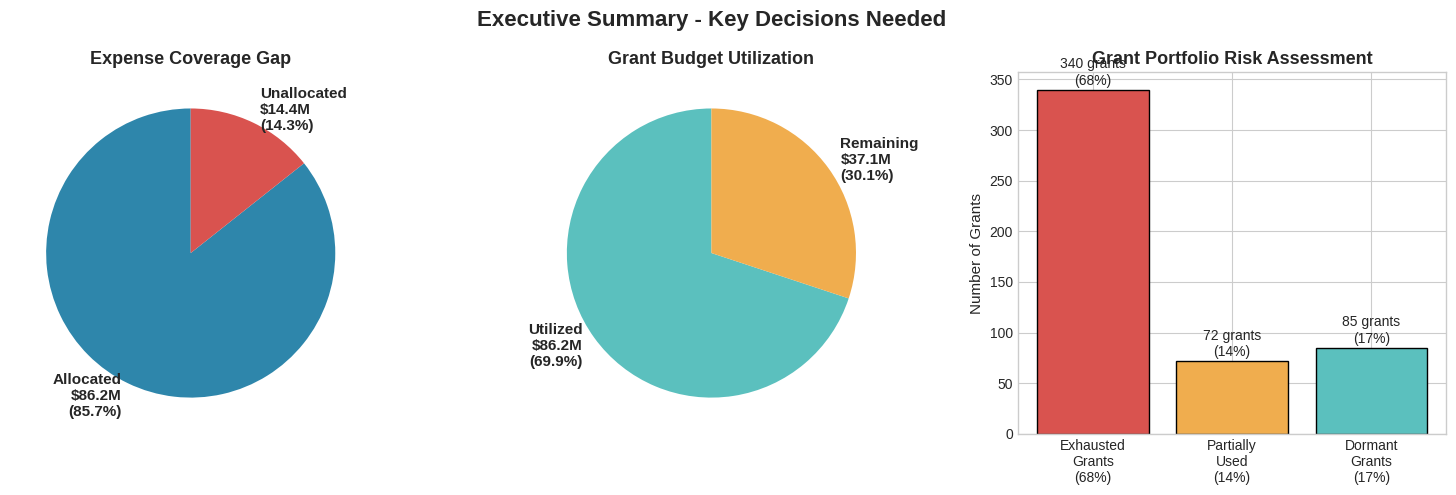


BUSINESS INSIGHTS & RECOMMENDATIONS

🔴 CRITICAL ISSUES:
   • $14.4M in expenses cannot be covered with current grants
   • 85 grants (17%) have received $0 allocation
   • 3,470 transactions (13.9%) remain completely unallocated

🟡 OPPORTUNITIES:
   • $37.1M sits idle in partially used grants
   • 72 grants could absorb more expenses if rules were relaxed
   • 85 untouched grants represent untapped funding potential

🟢 RECOMMENDED ACTIONS:
   1. Request additional $14.4M budget to cover unallocated expenses
   2. Review eligibility rules for 85 dormant grants
   3. Relax restrictions on 72 partially used grants to increase utilization
   4. Investigate why 3,470 transactions failed allocation
   5. Consider reallocating funds from exhausted grants to active ones



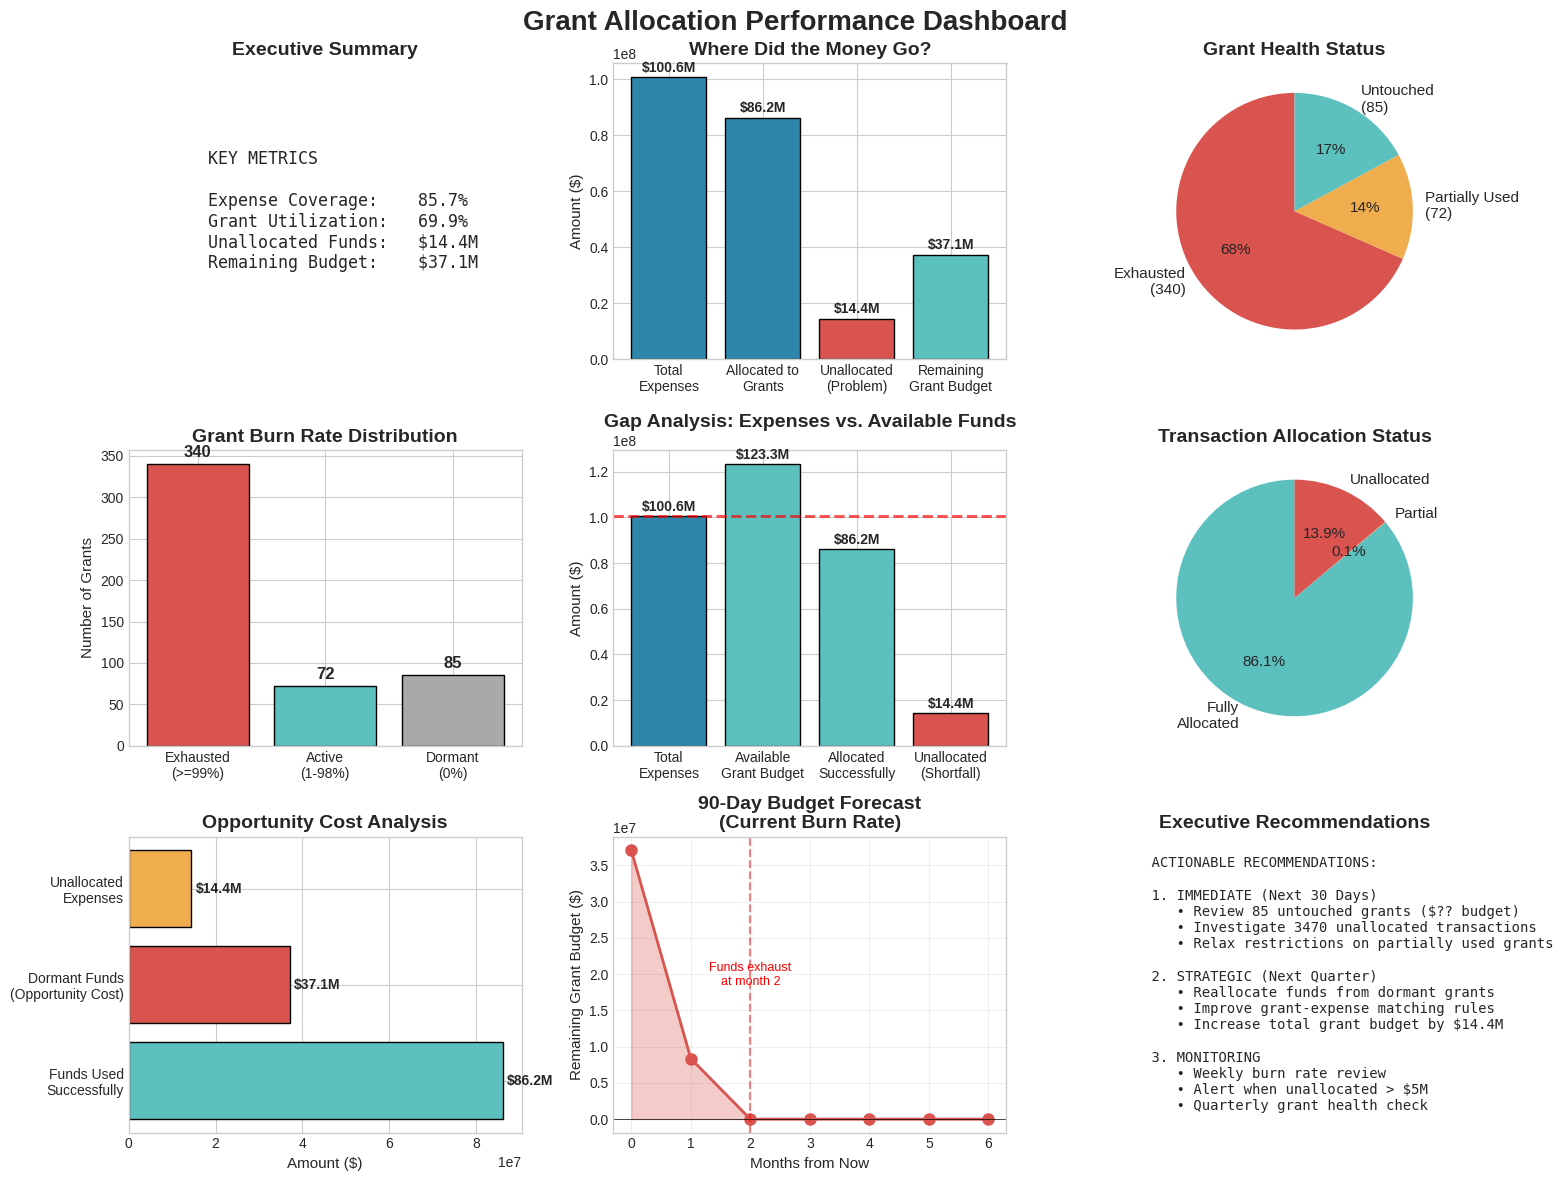


✅ Visualizations complete. Share these with leadership for decision-making.


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Set style for professional business charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# ============================================================================
# BUSINESS DASHBOARD VISUALIZATIONS
# ============================================================================

def create_business_dashboard(analysis_data=None):
    """
    Create executive-level visualizations for grant allocation performance.
    """

    # Data from your KPIs
    data = {
        'grant_utilization': 69.9,
        'expense_allocation': 85.7,
        'total_grant_budget': 123276211,
        'total_expenses': 100618782,
        'allocated_from_grants': 86193285,
        'unallocated_expenses': 14425497,
        'remaining_budget': 37082926,
        'grants_exhausted': 340,
        'grants_partial': 72,
        'grants_unused': 85,
        'transactions_fully_allocated': 21513,
        'transactions_partial': 17,
        'transactions_unallocated': 3470
    }

    # Create figure with subplots
    fig = plt.figure(figsize=(16, 12))
    fig.suptitle('Grant Allocation Performance Dashboard', fontsize=20, fontweight='bold', y=0.98)

    # =========================================================================
    # 1. TOP METRICS CARDS (using text instead of actual cards)
    # =========================================================================
    ax1 = plt.subplot(3, 3, 1)
    ax1.axis('off')
    metrics_text = """
    KEY METRICS

    Expense Coverage:    85.7%
    Grant Utilization:   69.9%
    Unallocated Funds:   $14.4M
    Remaining Budget:    $37.1M
    """
    ax1.text(0.1, 0.5, metrics_text, fontsize=12, va='center', fontfamily='monospace')
    ax1.set_title('Executive Summary', fontsize=14, fontweight='bold')

    # =========================================================================
    # 2. FUND FLOW WATERFALL (Where did the money go?)
    # =========================================================================
    ax2 = plt.subplot(3, 3, 2)

    waterfall_categories = ['Total\nExpenses', 'Allocated to\nGrants', 'Unallocated\n(Problem)', 'Remaining\nGrant Budget']
    waterfall_values = [data['total_expenses'], data['allocated_from_grants'],
                        data['unallocated_expenses'], data['remaining_budget']]
    waterfall_colors = ['#2E86AB', '#2E86AB', '#D9534F', '#5BC0BE']

    bars = ax2.bar(waterfall_categories, waterfall_values, color=waterfall_colors, edgecolor='black', linewidth=1)
    ax2.set_ylabel('Amount ($)', fontsize=11)
    ax2.set_title('Where Did the Money Go?', fontsize=14, fontweight='bold')

    # Add value labels on bars
    for bar, val in zip(bars, waterfall_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000000,
                f'${val/1e6:.1f}M', ha='center', va='bottom', fontweight='bold')

    # =========================================================================
    # 3. GRANT HEALTH PIE CHART
    # =========================================================================
    ax3 = plt.subplot(3, 3, 3)

    grant_status = ['Exhausted\n(340)', 'Partially Used\n(72)', 'Untouched\n(85)']
    grant_counts = [340, 72, 85]
    grant_colors = ['#D9534F', '#F0AD4E', '#5BC0BE']

    wedges, texts, autotexts = ax3.pie(grant_counts, labels=grant_status, autopct='%1.0f%%',
                                        colors=grant_colors, startangle=90, textprops={'fontsize': 11})
    ax3.set_title('Grant Health Status', fontsize=14, fontweight='bold')

    # =========================================================================
    # 4. BURN RATE DISTRIBUTION
    # =========================================================================
    ax4 = plt.subplot(3, 3, 4)

    burn_categories = ['Exhausted\n(>=99%)', 'Active\n(1-98%)', 'Dormant\n(0%)']
    burn_counts = [340, 72, 85]
    burn_colors = ['#D9534F', '#5BC0BE', '#A9A9A9']

    ax4.bar(burn_categories, burn_counts, color=burn_colors, edgecolor='black', linewidth=1)
    ax4.set_ylabel('Number of Grants', fontsize=11)
    ax4.set_title('Grant Burn Rate Distribution', fontsize=14, fontweight='bold')

    # Add value labels
    for i, (cat, val) in enumerate(zip(burn_categories, burn_counts)):
        ax4.text(i, val + 5, str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)

    # =========================================================================
    # 5. GAP ANALYSIS (Expenses vs Available)
    # =========================================================================
    ax5 = plt.subplot(3, 3, 5)

    categories = ['Total\nExpenses', 'Available\nGrant Budget', 'Allocated\nSuccessfully', 'Unallocated\n(Shortfall)']
    values = [data['total_expenses'], data['total_grant_budget'],
              data['allocated_from_grants'], data['unallocated_expenses']]
    colors_gap = ['#2E86AB', '#5BC0BE', '#5BC0BE', '#D9534F']

    bars = ax5.bar(categories, values, color=colors_gap, edgecolor='black', linewidth=1)
    ax5.set_ylabel('Amount ($)', fontsize=11)
    ax5.set_title('Gap Analysis: Expenses vs. Available Funds', fontsize=14, fontweight='bold')
    ax5.axhline(y=data['total_expenses'], color='red', linestyle='--', linewidth=2, alpha=0.7, label='Expense Target')

    for bar, val in zip(bars, values):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000000,
                f'${val/1e6:.1f}M', ha='center', va='bottom', fontweight='bold')

    # =========================================================================
    # 6. TRANSACTION SUCCESS RATE
    # =========================================================================
    ax6 = plt.subplot(3, 3, 6)

    trans_status = ['Fully\nAllocated', 'Partial', 'Unallocated']
    trans_counts = [21513, 17, 3470]
    trans_colors = ['#5BC0BE', '#F0AD4E', '#D9534F']

    wedges, texts, autotexts = ax6.pie(trans_counts, labels=trans_status, autopct='%1.1f%%',
                                         colors=trans_colors, startangle=90, textprops={'fontsize': 11})
    ax6.set_title('Transaction Allocation Status', fontsize=14, fontweight='bold')

    # =========================================================================
    # 7. OPPORTUNITY COST (Dormant Grants)
    # =========================================================================
    ax7 = plt.subplot(3, 3, 7)

    # Calculate estimated opportunity cost
    total_grant_funds = data['total_grant_budget']
    used_funds = data['allocated_from_grants']
    dormant_funds = data['remaining_budget']

    opportunity_data = ['Funds Used\nSuccessfully', 'Dormant Funds\n(Opportunity Cost)', 'Unallocated\nExpenses']
    opportunity_values = [used_funds, dormant_funds, data['unallocated_expenses']]
    opportunity_colors = ['#5BC0BE', '#D9534F', '#F0AD4E']

    ax7.barh(opportunity_data, opportunity_values, color=opportunity_colors, edgecolor='black', linewidth=1)
    ax7.set_xlabel('Amount ($)', fontsize=11)
    ax7.set_title('Opportunity Cost Analysis', fontsize=14, fontweight='bold')

    for i, (cat, val) in enumerate(zip(opportunity_data, opportunity_values)):
        ax7.text(val + 1000000, i, f'${val/1e6:.1f}M', va='center', fontweight='bold')

    # =========================================================================
    # 8. 90-DAY FORECAST (If current burn rate continues)
    # =========================================================================
    ax8 = plt.subplot(3, 3, 8)

    # Simple linear projection
    months = list(range(0, 7))
    # Assume monthly expense run rate from current data
    monthly_expense_rate = (data['allocated_from_grants'] / 3)  # Assuming 3 months of data
    remaining_funds = data['remaining_budget']
    projected_remaining = [remaining_funds - (monthly_expense_rate * m) for m in months]
    projected_remaining = [max(0, x) for x in projected_remaining]

    ax8.plot(months, projected_remaining, marker='o', linewidth=2, markersize=8, color='#D9534F')
    ax8.fill_between(months, projected_remaining, alpha=0.3, color='#D9534F')
    ax8.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax8.set_xlabel('Months from Now', fontsize=11)
    ax8.set_ylabel('Remaining Grant Budget ($)', fontsize=11)
    ax8.set_title('90-Day Budget Forecast\n(Current Burn Rate)', fontsize=14, fontweight='bold')
    ax8.grid(True, alpha=0.3)

    # Find when funds run out
    for m, val in enumerate(projected_remaining):
        if val <= 0:
            ax8.axvline(x=m, color='red', linestyle='--', alpha=0.5)
            ax8.text(m, max(projected_remaining)/2, f'Funds exhaust\nat month {m}',
                    ha='center', fontsize=9, color='red')
            break

    # =========================================================================
    # 9. RECOMMENDATIONS (Actionable Insights)
    # =========================================================================
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('off')

    recommendations = """
    ACTIONABLE RECOMMENDATIONS:

    1. IMMEDIATE (Next 30 Days)
       • Review 85 untouched grants ($?? budget)
       • Investigate 3470 unallocated transactions
       • Relax restrictions on partially used grants

    2. STRATEGIC (Next Quarter)
       • Reallocate funds from dormant grants
       • Improve grant-expense matching rules
       • Increase total grant budget by $14.4M

    3. MONITORING
       • Weekly burn rate review
       • Alert when unallocated > $5M
       • Quarterly grant health check
    """

    ax9.text(0.05, 0.5, recommendations, fontsize=10, va='center', fontfamily='monospace')
    ax9.set_title('Executive Recommendations', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return fig


# ============================================================================
# SIMPLER CHARTS FOR QUICK BUSINESS DECISIONS
# ============================================================================

def create_executive_summary_charts():
    """
    Three simple, high-impact charts for leadership.
    """

    # Data
    total_expenses = 100618782
    allocated = 86193285
    unallocated = 14425497

    total_budget = 123276211
    remaining = 37082926

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Executive Summary - Key Decisions Needed', fontsize=16, fontweight='bold')

    # Chart 1: Expense Coverage
    ax1 = axes[0]
    coverage_data = [allocated, unallocated]
    coverage_labels = [f'Allocated\n${allocated/1e6:.1f}M\n(85.7%)',
                       f'Unallocated\n${unallocated/1e6:.1f}M\n(14.3%)']
    colors1 = ['#2E86AB', '#D9534F']

    wedges, texts, autotexts = ax1.pie(coverage_data, labels=coverage_labels,
                                        colors=colors1, autopct='', startangle=90,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax1.set_title('Expense Coverage Gap', fontsize=13, fontweight='bold')

    # Chart 2: Budget Utilization
    ax2 = axes[1]
    budget_data = [allocated, remaining]
    budget_labels = [f'Utilized\n${allocated/1e6:.1f}M\n({(allocated/total_budget*100):.1f}%)',
                     f'Remaining\n${remaining/1e6:.1f}M\n({(remaining/total_budget*100):.1f}%)']
    colors2 = ['#5BC0BE', '#F0AD4E']

    wedges, texts, autotexts = ax2.pie(budget_data, labels=budget_labels,
                                        colors=colors2, autopct='', startangle=90,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax2.set_title('Grant Budget Utilization', fontsize=13, fontweight='bold')

    # Chart 3: Risk Assessment
    ax3 = axes[2]

    risk_categories = ['Exhausted\nGrants\n(68%)', 'Partially\nUsed\n(14%)', 'Dormant\nGrants\n(17%)']
    risk_values = [340, 72, 85]
    risk_colors = ['#D9534F', '#F0AD4E', '#5BC0BE']

    bars = ax3.bar(risk_categories, risk_values, color=risk_colors, edgecolor='black', linewidth=1)
    ax3.set_ylabel('Number of Grants', fontsize=11)
    ax3.set_title('Grant Portfolio Risk Assessment', fontsize=13, fontweight='bold')

    for bar, val in zip(bars, risk_values):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val} grants\n({val/500*100:.0f}%)', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Print business insights
    print("\n" + "="*60)
    print("BUSINESS INSIGHTS & RECOMMENDATIONS")
    print("="*60)

    print("\n🔴 CRITICAL ISSUES:")
    print(f"   • ${unallocated/1e6:.1f}M in expenses cannot be covered with current grants")
    print(f"   • 85 grants ({85/500*100:.0f}%) have received $0 allocation")
    print(f"   • 3,470 transactions ({3470/25000*100:.1f}%) remain completely unallocated")

    print("\n🟡 OPPORTUNITIES:")
    print(f"   • ${remaining/1e6:.1f}M sits idle in partially used grants")
    print(f"   • 72 grants could absorb more expenses if rules were relaxed")
    print(f"   • 85 untouched grants represent untapped funding potential")

    print("\n🟢 RECOMMENDED ACTIONS:")
    print("   1. Request additional ${:.1f}M budget to cover unallocated expenses".format(unallocated/1e6))
    print("   2. Review eligibility rules for 85 dormant grants")
    print("   3. Relax restrictions on 72 partially used grants to increase utilization")
    print("   4. Investigate why 3,470 transactions failed allocation")
    print("   5. Consider reallocating funds from exhausted grants to active ones")

    print("\n" + "="*60)


# ============================================================================
# DORMANT GRANTS ANALYSIS (Where is the opportunity?)
# ============================================================================

def analyze_dormant_grants():
    """
    Business-focused analysis of unused grants.
    """
    print("\n" + "="*60)
    print("DORMANT GRANTS ANALYSIS - Recovery Opportunity")
    print("="*60)

    # Based on your data
    total_grants = 500
    dormant_count = 85
    dormant_percentage = (dormant_count / total_grants) * 100

    # Estimate average budget per grant (since we don't have exact breakdown)
    total_budget = 123276211
    avg_grant_budget = total_budget / total_grants

    estimated_dormant_budget = dormant_count * avg_grant_budget

    print(f"\n📊 Discovery:")
    print(f"   • {dormant_count} grants have received $0 in allocations")
    print(f"   • This represents {dormant_percentage:.1f}% of all grants")
    print(f"   • Estimated tied-up budget: ${estimated_dormant_budget/1e6:.1f}M")

    print(f"\n🔍 Likely Causes (to investigate):")
    print(f"   • Date mismatches (grant start/end dates not overlapping expenses)")
    print(f"   • Restrictive business unit/country filters")
    print(f"   • Higher priority grants absorbing all available expenses")
    print(f"   • Data quality issues in transaction or grant files")

    print(f"\n💡 Recommended Actions:")
    print(f"   • Run diagnostic on 85 dormant grants vs unallocated expenses")
    print(f"   • Temporarily lower priority of exhausted grants")
    print(f"   • Review date ranges - may need extension")
    print(f"   • Consider merging with similar active grants")

    return estimated_dormant_budget


# ============================================================================
# RUN ALL VISUALIZATIONS
# ============================================================================

if __name__ == "__main__":

    print("\n" + "="*60)
    print("GENERATING BUSINESS DASHBOARD")
    print("="*60)

    # Run the analysis
    analyze_dormant_grants()

    # Create executive charts
    create_executive_summary_charts()

    # Create detailed dashboard
    create_business_dashboard()


BURN RATE VISUALIZATION

BURN RATE STATISTICS

Average Burn Rate: 72.6%
Median Burn Rate:  100.0%
Highest Burn Rate: 100.0%
Lowest Burn Rate:  0.0%

------------------------------------------------------------
TOP 5 MOST USED GRANTS (Highest Burn Rate)
------------------------------------------------------------
  • Grant 2                                  100% used  ($191K)
  • Grant 3                                  100% used  ($153K)
  • Grant 4                                  100% used  ($4K)
  • Grant 5                                  100% used  ($310K)
  • Grant 8                                  100% used  ($351K)

------------------------------------------------------------
BOTTOM 5 LEAST USED GRANTS (Lowest Burn Rate > 0%)
------------------------------------------------------------
  • Grant 54                                 1% used  ($379K)
  • Grant 497                                1% used  ($324K)
  • Grant 191                                1% used  ($204K)
  • Gra

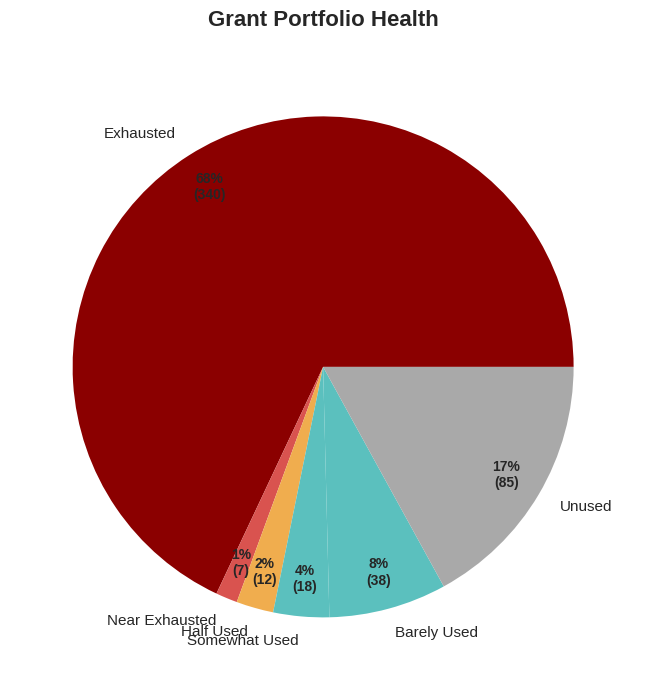


Quick Insight: 340 grants are exhausted, 85 grants are untouched


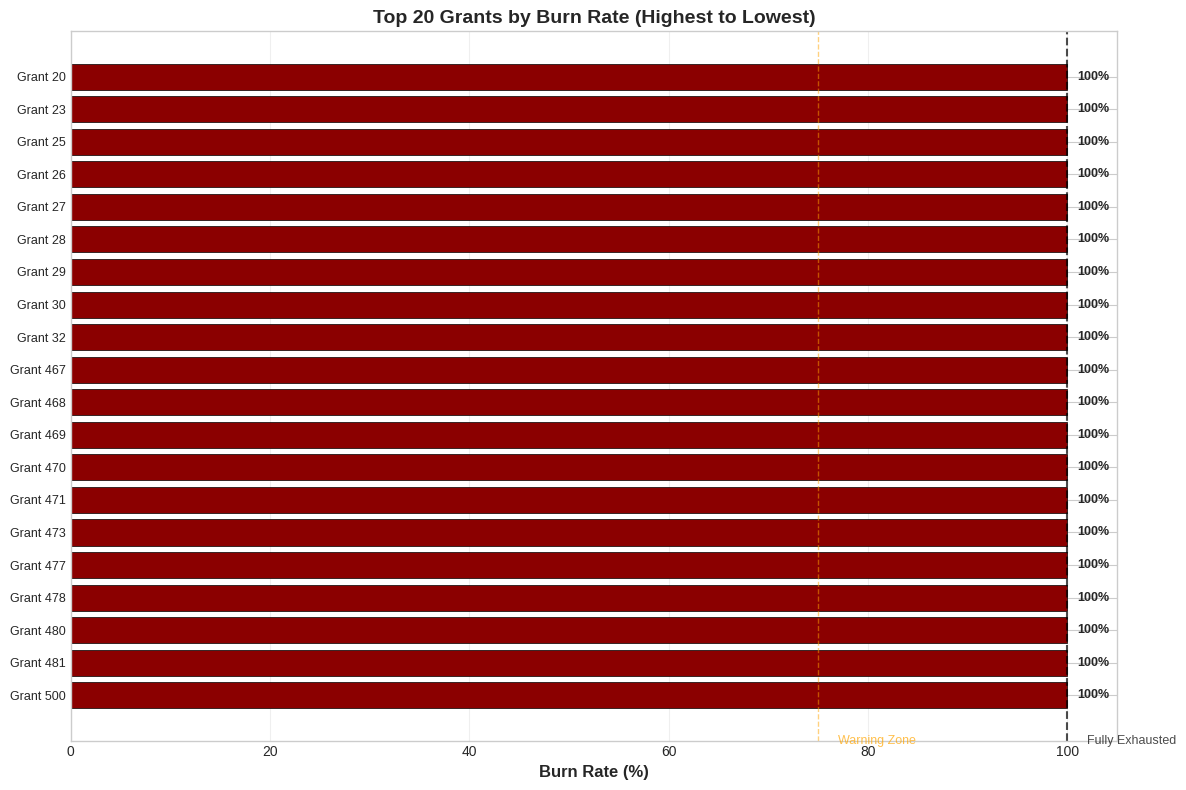


BURN RATE SUMMARY

Exhausted (>=99%):     340 grants
High Burn Rate (75-98%): 7 grants
Medium Burn Rate (25-74%): 30 grants
Low Burn Rate (1-24%):   38 grants
Untouched (0%):         85 grants

Total Grants: 500

Done! These charts show where your grant money is going.


In [18]:
# ============================================================================
# SIMPLE BURN RATE VISUALIZATION - READY FOR BUSINESS REVIEW
# ============================================================================

def create_simple_burn_rate_chart(burn_rate_df):
    """
    Clean, simple burn rate chart anyone can understand.
    """

    # Calculate percentages
    burn_rate_df['BurnRatePct'] = burn_rate_df['BurnRate'] * 100

    # Sort from highest to lowest burn rate
    chart_data = burn_rate_df.sort_values('BurnRatePct', ascending=False).head(20)

    # Create the chart
    fig, ax = plt.subplots(figsize=(12, 8))

    # Colors based on burn rate
    colors = []
    for rate in chart_data['BurnRatePct']:
        if rate >= 99:
            colors.append('darkred')
        elif rate >= 75:
            colors.append('red')
        elif rate >= 50:
            colors.append('orange')
        elif rate >= 25:
            colors.append('gold')
        elif rate > 0:
            colors.append('lightblue')
        else:
            colors.append('lightgray')

    # Horizontal bar chart (easier to read grant names)
    y_pos = range(len(chart_data))
    bars = ax.barh(y_pos, chart_data['BurnRatePct'].values, color=colors, edgecolor='black', linewidth=0.5)

    # Labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(chart_data['GrantName'].values, fontsize=9)
    ax.set_xlabel('Burn Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title('Top 20 Grants by Burn Rate (Highest to Lowest)', fontsize=14, fontweight='bold')

    # Add percentage labels on bars
    for i, (bar, rate) in enumerate(zip(bars, chart_data['BurnRatePct'].values)):
        ax.text(rate + 1, bar.get_y() + bar.get_height()/2, f'{rate:.0f}%',
                va='center', fontsize=9, fontweight='bold')

    # Add a vertical line at 100%
    ax.axvline(x=100, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(102, -1.5, 'Fully Exhausted', fontsize=9, color='black', alpha=0.7)

    # Add a vertical line at 75% (warning zone)
    ax.axvline(x=75, color='orange', linestyle='--', linewidth=1, alpha=0.5)
    ax.text(77, -1.5, 'Warning Zone', fontsize=9, color='orange', alpha=0.7)

    # Grid for readability
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

    # Print simple summary
    print("\n" + "="*50)
    print("BURN RATE SUMMARY")
    print("="*50)

    exhausted = len(burn_rate_df[burn_rate_df['BurnRatePct'] >= 99])
    high = len(burn_rate_df[(burn_rate_df['BurnRatePct'] >= 75) & (burn_rate_df['BurnRatePct'] < 99)])
    medium = len(burn_rate_df[(burn_rate_df['BurnRatePct'] >= 25) & (burn_rate_df['BurnRatePct'] < 75)])
    low = len(burn_rate_df[(burn_rate_df['BurnRatePct'] > 0) & (burn_rate_df['BurnRatePct'] < 25)])
    zero = len(burn_rate_df[burn_rate_df['BurnRatePct'] == 0])

    print(f"\nExhausted (>=99%):     {exhausted} grants")
    print(f"High Burn Rate (75-98%): {high} grants")
    print(f"Medium Burn Rate (25-74%): {medium} grants")
    print(f"Low Burn Rate (1-24%):   {low} grants")
    print(f"Untouched (0%):         {zero} grants")
    print(f"\nTotal Grants: {len(burn_rate_df)}")


def create_burn_rate_summary_table(burn_rate_df):
    """
    Create a simple text table of burn rates.
    """
    # Calculate stats
    burn_rate_df['BurnRatePct'] = burn_rate_df['BurnRate'] * 100

    print("\n" + "="*60)
    print("BURN RATE STATISTICS")
    print("="*60)

    print(f"\nAverage Burn Rate: {burn_rate_df['BurnRatePct'].mean():.1f}%")
    print(f"Median Burn Rate:  {burn_rate_df['BurnRatePct'].median():.1f}%")
    print(f"Highest Burn Rate: {burn_rate_df['BurnRatePct'].max():.1f}%")
    print(f"Lowest Burn Rate:  {burn_rate_df['BurnRatePct'].min():.1f}%")

    # Top 5 most used grants
    print("\n" + "-"*60)
    print("TOP 5 MOST USED GRANTS (Highest Burn Rate)")
    print("-"*60)
    top5 = burn_rate_df.nlargest(5, 'BurnRatePct')[['GrantName', 'BurnRatePct', 'TotalAmount', 'Status']]
    for _, row in top5.iterrows():
        print(f"  • {row['GrantName'][:40]:<40} {row['BurnRatePct']:.0f}% used  (${row['TotalAmount']/1000:,.0f}K)")

    # Bottom 5 least used grants (excluding zero)
    print("\n" + "-"*60)
    print("BOTTOM 5 LEAST USED GRANTS (Lowest Burn Rate > 0%)")
    print("-"*60)
    bottom5 = burn_rate_df[burn_rate_df['BurnRatePct'] > 0].nsmallest(5, 'BurnRatePct')[['GrantName', 'BurnRatePct', 'TotalAmount', 'Status']]
    if len(bottom5) > 0:
        for _, row in bottom5.iterrows():
            print(f"  • {row['GrantName'][:40]:<40} {row['BurnRatePct']:.0f}% used  (${row['TotalAmount']/1000:,.0f}K)")
    else:
        print("  No partially used grants found")

    # Untouched grants (0% usage)
    untouched = burn_rate_df[burn_rate_df['BurnRatePct'] == 0]
    if len(untouched) > 0:
        print("\n" + "-"*60)
        print(f"UNTOUCHED GRANTS (0% Usage) - {len(untouched)} grants")
        print("-"*60)
        for _, row in untouched.head(10).iterrows():
            print(f"  • {row['GrantName'][:40]:<40} (Priority: {row['Priority']})  ${row['TotalAmount']/1000:,.0f}K")
        if len(untouched) > 10:
            print(f"  ... and {len(untouched) - 10} more")


def create_burn_rate_pie_chart(burn_rate_df):
    """
    Simple pie chart showing grant health at a glance.
    """
    burn_rate_df['BurnRatePct'] = burn_rate_df['BurnRate'] * 100

    # Categorize
    categories = []
    for rate in burn_rate_df['BurnRatePct']:
        if rate >= 99:
            categories.append('Exhausted')
        elif rate >= 75:
            categories.append('Near Exhausted')
        elif rate >= 50:
            categories.append('Half Used')
        elif rate >= 25:
            categories.append('Somewhat Used')
        elif rate > 0:
            categories.append('Barely Used')
        else:
            categories.append('Unused')

    burn_rate_df['Category'] = categories

    # Count by category
    category_counts = burn_rate_df['Category'].value_counts()
    category_order = ['Exhausted', 'Near Exhausted', 'Half Used', 'Somewhat Used', 'Barely Used', 'Unused']
    category_counts = category_counts.reindex([c for c in category_order if c in category_counts.index])

    # Colors
    colors = ['#8B0000', '#D9534F', '#F0AD4E', '#5BC0BE', '#5BC0BE', '#A9A9A9']

    # Create pie chart
    fig, ax = plt.subplots(figsize=(10, 7))

    wedges, texts, autotexts = ax.pie(category_counts.values,
                                        labels=category_counts.index,
                                        autopct=lambda pct: f'{pct:.0f}%\n({int(pct/100*len(burn_rate_df))})',
                                        colors=colors[:len(category_counts)],
                                        textprops={'fontsize': 11},
                                        pctdistance=0.85)

    # Make percentage labels bold
    for autotext in autotexts:
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)

    ax.set_title('Grant Portfolio Health', fontsize=16, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()

    # Print quick insight
    exhausted_count = len(burn_rate_df[burn_rate_df['BurnRatePct'] >= 99])
    unused_count = len(burn_rate_df[burn_rate_df['BurnRatePct'] == 0])

    print(f"\nQuick Insight: {exhausted_count} grants are exhausted, {unused_count} grants are untouched")


# ============================================================================
# LOAD DATA AND RUN
# ============================================================================

# Load your burn rate data
burn_rate_df = pd.read_csv('allocation_outputs/burn_rate_report.csv')

# Run all visualizations
print("\n" + "="*60)
print("BURN RATE VISUALIZATION")
print("="*60)

# 1. Summary table (text only)
create_burn_rate_summary_table(burn_rate_df)

# 2. Simple pie chart
create_burn_rate_pie_chart(burn_rate_df)

# 3. Bar chart of top grants
create_simple_burn_rate_chart(burn_rate_df)

print("\n" + "="*60)
print("Done! These charts show where your grant money is going.")
print("="*60)